# 10-Year Bond Yield Prediction (PyTorch Stacked LSTM)

## Overview
This notebook implements an **improved** 3-layer stacked LSTM model using **PyTorch** to predict the **future 5-day changes** of the 10-year Chinese government bond yield.

## Architecture
- **Framework**: PyTorch
- **Model**: Stacked LSTM (128 -> 64 -> 32 units) + Dense (32 -> 5)
- **Regularization**: Dropout (0.3)
- **Optimizer**: Adam with ReduceLROnPlateau
- **Loss Function**: MSE

## Data Processing
1. **Load Data**: Read the CSV file, cleaning metadata and footers.
2. **Differencing**: Compute the 1st order difference to make the time series stationary.
3. **Normalization**: Scale the data to [-1, 1] using MinMaxScaler (Fit on **Training Set Only**).
4. **Sequence Creation**: Create sliding window samples (Input: 60 days, Output: 5 days).
5. **Splitting**:
    - Train+Val: First 80%
    - Test: Last 20%
    - Train: First 90% of Train+Val
    - Val: Last 10% of Train+Val


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

%matplotlib inline

Using device: cpu


In [2]:
def load_data(filepath):
    try:
        df = pd.read_csv(filepath, skiprows=8, header=None, encoding='gbk', names=['Date', 'Yield'])
    except Exception as e:
        print(f"Error reading csv: {e}")
        return None

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df = df.sort_values('Date')
    df['Yield'] = pd.to_numeric(df['Yield'], errors='coerce')
    df = df.dropna(subset=['Yield'])
    return df.reset_index(drop=True)

filepath = '中债国债到期收益率_10年.csv'
df = load_data(filepath)
print(f"Loaded {len(df)} rows.")

Loaded 1238 rows.


In [3]:
# 1. First Order Difference
df['Yield_Diff'] = df['Yield'].diff()
df_diff = df.dropna().reset_index(drop=True)

# 2. Determine Split Index for Scaling
N = len(df_diff)
window_size = 60
horizon = 5
num_samples = N - window_size - horizon + 1

# Calculate split points based on sample count
train_val_split_idx = int(num_samples * 0.8)
train_split_idx = int(train_val_split_idx * 0.9)

# Fit scaler on raw data corresponding to TRAINING inputs ONLY
scaler_fit_end_idx = train_split_idx + window_size

print(f"Total Data Points: {N}")
print(f"Total Samples: {num_samples}")
print(f"Train Samples: {train_split_idx}")
print(f"Fitting scaler on first {scaler_fit_end_idx} data points.")

# 3. Normalize (Fit on Train ONLY)
scaler = MinMaxScaler(feature_range=(-1, 1))
train_data = df_diff[['Yield_Diff']].iloc[:scaler_fit_end_idx]
scaler.fit(train_data)

# Transform entire dataset
data_scaled = scaler.transform(df_diff[['Yield_Diff']])

# 4. Create Sequences
X, y = [], []
for i in range(num_samples):
    x_seq = data_scaled[i : i + window_size]
    y_seq = data_scaled[i + window_size : i + window_size + horizon]
    X.append(x_seq)
    y.append(y_seq)

X = np.array(X)
y = np.array(y)
y = y.reshape(y.shape[0], horizon)

print(f"X shape: {X.shape}, y shape: {y.shape}")

Total Data Points: 1237
Total Samples: 1173
Train Samples: 844
Fitting scaler on first 904 data points.
X shape: (1173, 60, 1), y shape: (1173, 5)


In [4]:
X_train_val = X[:train_val_split_idx]
y_train_val = y[:train_val_split_idx]

X_test = X[train_val_split_idx:]
y_test = y[train_val_split_idx:]

X_train = X_train_val[:train_split_idx]
y_train = y_train_val[:train_split_idx]

X_val = X_train_val[train_split_idx:]
y_val = y_train_val[train_split_idx:]

print(f"Train Set: {X_train.shape}")
print(f"Val Set:   {X_val.shape}")
print(f"Test Set:  {X_test.shape}")

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # Time series, usually shuffle=False or True if stateless
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train Set: (844, 60, 1)
Val Set:   (94, 60, 1)
Test Set:  (235, 60, 1)


In [5]:
class BondYieldLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_dims=[128, 64, 32], dense_dims=[32, 5], dropout_prob=0.3):
        super(BondYieldLSTM, self).__init__()
        
        # Layer 1: LSTM 128
        self.lstm1 = nn.LSTM(input_size, hidden_dims[0], batch_first=True)
        self.dropout1 = nn.Dropout(dropout_prob)
        
        # Layer 2: LSTM 64
        self.lstm2 = nn.LSTM(hidden_dims[0], hidden_dims[1], batch_first=True)
        self.dropout2 = nn.Dropout(dropout_prob)
        
        # Layer 3: LSTM 32
        self.lstm3 = nn.LSTM(hidden_dims[1], hidden_dims[2], batch_first=True)
        self.dropout3 = nn.Dropout(dropout_prob)
        
        # Dense Layers
        self.fc1 = nn.Linear(hidden_dims[2], dense_dims[0])
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_dims[0], dense_dims[1])
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        
        # LSTM 1
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        
        # LSTM 2
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        
        # LSTM 3
        out, (h_n, c_n) = self.lstm3(out)
        # out shape: (batch, seq_len, hidden_size)
        # We need the output of the last time step
        out = out[:, -1, :] 
        out = self.dropout3(out)
        
        # Dense layers
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        
        return out

model = BondYieldLSTM().to(device)
print(model)

BondYieldLSTM(
  (lstm1): LSTM(1, 128, batch_first=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(128, 64, batch_first=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (lstm3): LSTM(64, 32, batch_first=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=5, bias=True)
)


Starting training...


Epoch 1/100, Train Loss: 0.052714, Val Loss: 0.090094, LR: 0.001000


Epoch 10/100, Train Loss: 0.039721, Val Loss: 0.087346, LR: 0.000500


Early stopping at epoch 17


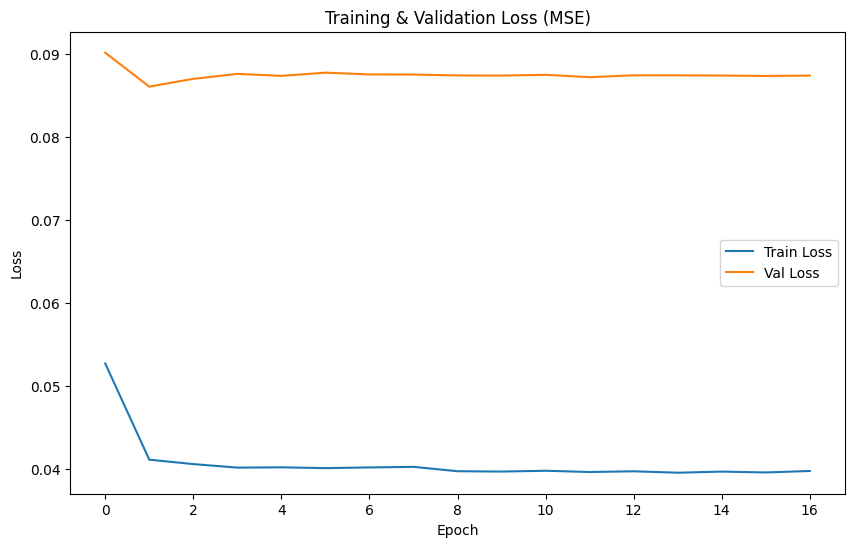

In [6]:
# Hyperparameters
learning_rate = 0.001
epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# Removing verbose=True as it might be deprecated in newer versions
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early Stopping Helper
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict()
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict()
            self.counter = 0

early_stopper = EarlyStopping(patience=15)

# Training Loop
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    scheduler.step(epoch_val_loss)
    early_stopper(epoch_val_loss, model)
    
    if (epoch+1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.6f}, Val Loss: {epoch_val_loss:.6f}, LR: {current_lr:.6f}")
        
    if early_stopper.early_stop:
        print(f"Early stopping at epoch {epoch+1}")
        model.load_state_dict(early_stopper.best_model_state)
        break

# Restore best weights if not stopped early but loop finished
if not early_stopper.early_stop and early_stopper.best_model_state:
    model.load_state_dict(early_stopper.best_model_state)

# Plot Training History
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training & Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
# Evaluate on Test Set
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        predictions.append(outputs.cpu().numpy())
        actuals.append(y_batch.cpu().numpy())

y_pred_scaled = np.concatenate(predictions)
y_test_scaled = np.concatenate(actuals)

# Inverse Transform
# Reshape to (N, 1) for inverse_transform, then reshape back
y_test_inv = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).reshape(y_test_scaled.shape)
y_pred_inv = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)

# Metrics
mse_real = mean_squared_error(y_test_inv, y_pred_inv)
mae_real = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"Test MSE (Real Scale): {mse_real:.6f}")
print(f"Test MAE (Real Scale): {mae_real:.6f}")

# Calculate metrics for each day of the horizon
for i in range(5):
    mae_day = mean_absolute_error(y_test_inv[:, i], y_pred_inv[:, i])
    print(f"Day {i+1} Horizon MAE: {mae_day:.6f}")

Test MSE (Real Scale): 0.000389
Test MAE (Real Scale): 0.013717
Day 1 Horizon MAE: 0.013959
Day 2 Horizon MAE: 0.013861
Day 3 Horizon MAE: 0.013774
Day 4 Horizon MAE: 0.013434
Day 5 Horizon MAE: 0.013557


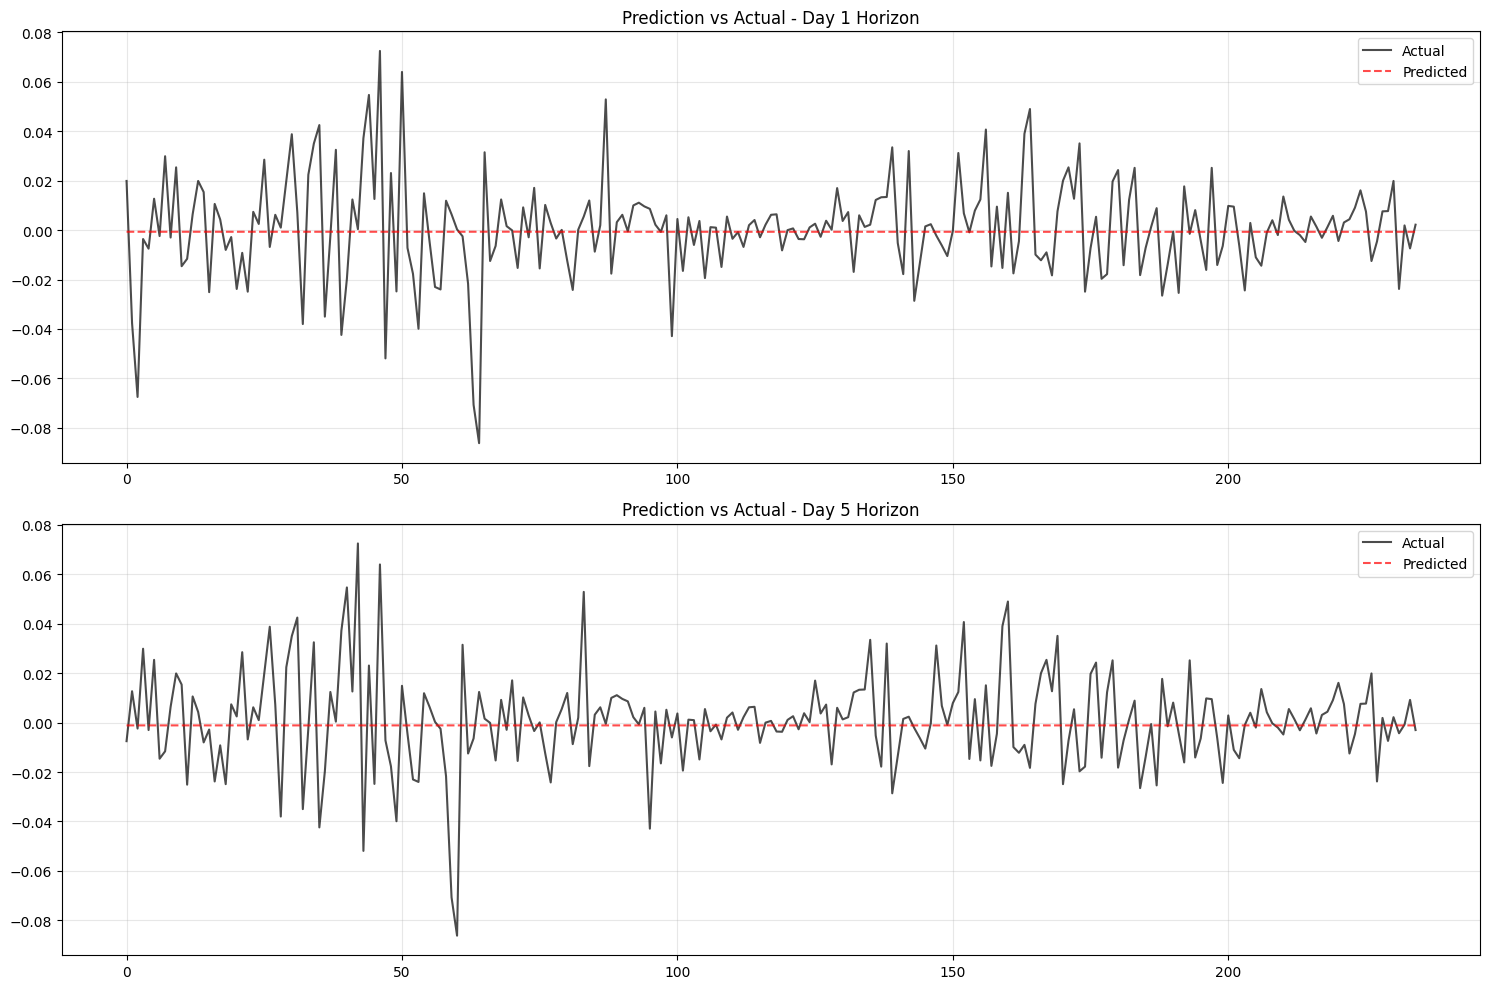

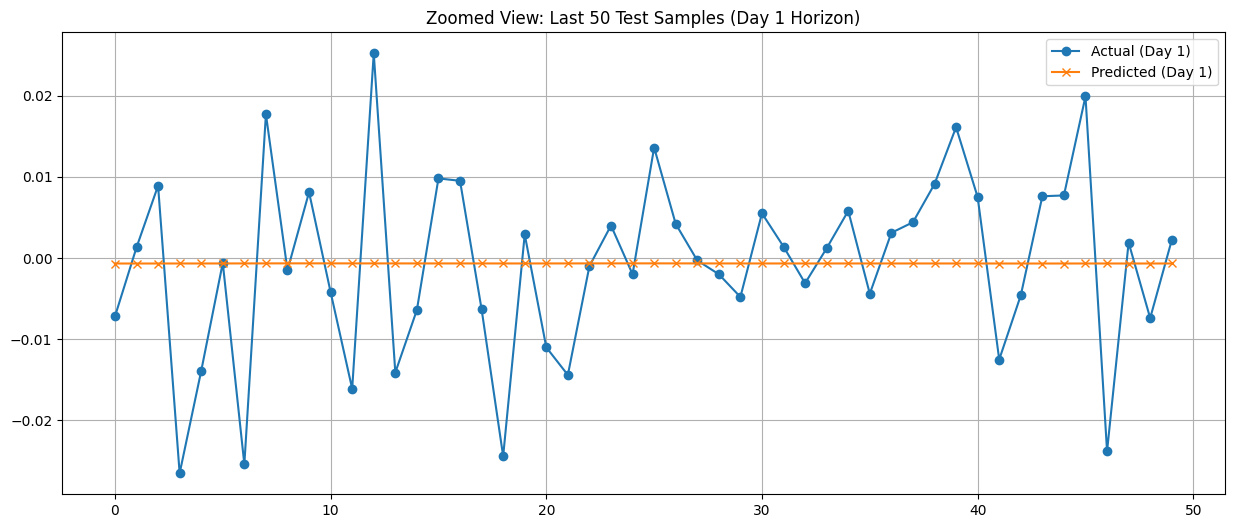

In [8]:
# Visualization
days_to_plot = [0, 4] # Day 1 and Day 5
plt.figure(figsize=(15, 10))

for idx, day_idx in enumerate(days_to_plot):
    plt.subplot(2, 1, idx+1)
    plt.plot(y_test_inv[:, day_idx], label='Actual', color='black', alpha=0.7)
    plt.plot(y_pred_inv[:, day_idx], label='Predicted', color='red', alpha=0.7, linestyle='--')
    plt.title(f'Prediction vs Actual - Day {day_idx+1} Horizon')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zoom in on last 50 days
plt.figure(figsize=(15, 6))
plt.plot(y_test_inv[-50:, 0], label='Actual (Day 1)', marker='o')
plt.plot(y_pred_inv[-50:, 0], label='Predicted (Day 1)', marker='x')
plt.title('Zoomed View: Last 50 Test Samples (Day 1 Horizon)')
plt.legend()
plt.grid(True)
plt.show()